# DIVA Dataset - Image Diversity Analysis in 2D Vector Space

This notebook analyzes training images from a DIVA dataset subset by projecting them into 2D space and identifying the most diverse images based on feature similarity.

## Import Required Libraries

## Configuration Parameters

In [8]:
# ============ ADJUSTABLE PARAMETERS ============

# DIVA dataset subset: "CB55", "CS18", or "CS863"
DIVA_SUBSET = "CB55"

# Number of images to select with highest differences
NUM_DIVERSE_IMAGES = 3

# ============================================

print(f"Configuration:")
print(f"  Dataset subset: {DIVA_SUBSET}")
print(f"  Number of diverse images to select: {NUM_DIVERSE_IMAGES}")

Configuration:
  Dataset subset: CB55
  Number of diverse images to select: 3


In [9]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


## Load DIVA Dataset

In [10]:
# DIVA dataset paths (using configured subset)
DIVA_BASE_PATH = Path("../00_data/DIVA-HisDB")
DIVA_SUBSET_PATH = DIVA_BASE_PATH / DIVA_SUBSET / f"img-{DIVA_SUBSET}" / "img"

# Find all images in the dataset
all_images = []
for split in ["public-test", "public-train"]:
    split_path = DIVA_SUBSET_PATH / split
    if split_path.exists():
        images = list(split_path.glob("*.jpg")) + list(split_path.glob("*.png"))
        all_images.extend(images)
        print(f"Found {len(images)} images in {split}")

print(f"\nTotal images: {len(all_images)}")

# Use training images if available, otherwise use all
train_images = list((DIVA_SUBSET_PATH / "public-train").glob("*.jpg")) + list((DIVA_SUBSET_PATH / "public-train").glob("*.png"))
if train_images:
    images_to_analyze = train_images
    split_name = "public-train"
else:
    images_to_analyze = all_images
    split_name = "all"

print(f"Using {len(images_to_analyze)} images from {split_name}")
images_to_analyze = sorted(images_to_analyze)

Found 10 images in public-test

Total images: 10
Using 10 images from all


## Extract Feature Vectors from Images

In [11]:
# Load pre-trained ResNet18 model for feature extraction
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load ResNet18 (remove final layer for feature extraction)
model = models.resnet18(pretrained=True)
model = torch.nn.Sequential(*list(model.children())[:-1])  # Remove classification layer
model = model.to(device)
model.eval()

# Image preprocessing
preprocess = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

# Extract features from all images
features_list = []
valid_images = []

print(f"\nExtracting features from {len(images_to_analyze)} images...")
for img_path in tqdm(images_to_analyze, desc="Feature extraction"):
    try:
        # Load and preprocess image
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_tensor = preprocess(img_rgb).unsqueeze(0).to(device)
        
        # Extract features
        with torch.no_grad():
            features = model(img_tensor)
            features = features.squeeze().cpu().numpy().flatten()
        
        features_list.append(features)
        valid_images.append(img_path)
    except Exception as e:
        continue

print(f"Successfully extracted features from {len(features_list)} images")

# Convert to numpy array
features_array = np.array(features_list)
print(f"Feature matrix shape: {features_array.shape}")

Using device: cuda

Extracting features from 10 images...


Feature extraction: 100%|██████████| 10/10 [00:02<00:00,  4.18it/s]

Successfully extracted features from 10 images
Feature matrix shape: (10, 512)


## Reduce Features to 2D Space using PCA

In [12]:
# Standardize features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_array)

# Apply PCA to reduce to 2D
pca = PCA(n_components=2)
features_2d = pca.fit_transform(features_scaled)

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.4f}")
print(f"2D feature matrix shape: {features_2d.shape}")

PCA explained variance ratio: [0.26623705 0.19495694]
Total variance explained: 0.4612
2D feature matrix shape: (10, 2)


## Calculate Pairwise Distances Between Images

In [13]:
# Calculate pairwise distances in 2D space
distances = euclidean_distances(features_2d)

# Find the N images with the highest pairwise distances
print(f"Searching for {NUM_DIVERSE_IMAGES} images with highest diversity...")

# Get all pairwise distances and sort them
distance_pairs = []
for i in range(len(features_2d)):
    for j in range(i + 1, len(features_2d)):
        distance_pairs.append((distances[i, j], i, j))

distance_pairs.sort(reverse=True)

# Strategy: For each possible combination, find the set with maximum minimum distance
from itertools import combinations

best_combination = None
best_min_distance = 0

# Generate all combinations of NUM_DIVERSE_IMAGES images
for combo in combinations(range(len(features_2d)), NUM_DIVERSE_IMAGES):
    # Calculate minimum distance in this combination
    min_dist = float('inf')
    for i in range(len(combo)):
        for j in range(i + 1, len(combo)):
            dist = distances[combo[i], combo[j]]
            min_dist = min(min_dist, dist)
    
    # Update best combination if this one is better
    if min_dist > best_min_distance:
        best_min_distance = min_dist
        best_combination = combo

selected_indices = best_combination
print(f"Selected image indices: {selected_indices}")
print(f"Minimum pairwise distance: {best_min_distance:.4f}")

# Print distances between selected images
print("\nPairwise distances:")
for i in range(len(selected_indices)):
    for j in range(i + 1, len(selected_indices)):
        idx1, idx2 = selected_indices[i], selected_indices[j]
        dist = distances[idx1, idx2]
        print(f"  Distance between image {idx1} and {idx2}: {dist:.4f}")

Searching for 3 images with highest diversity...
Selected image indices: (3, 5, 9)
Minimum pairwise distance: 37.4669

Pairwise distances:
  Distance between image 3 and 5: 37.4669
  Distance between image 3 and 9: 41.5977
  Distance between image 5 and 9: 43.2874


## Visualize Images in 2D Space with Annotations

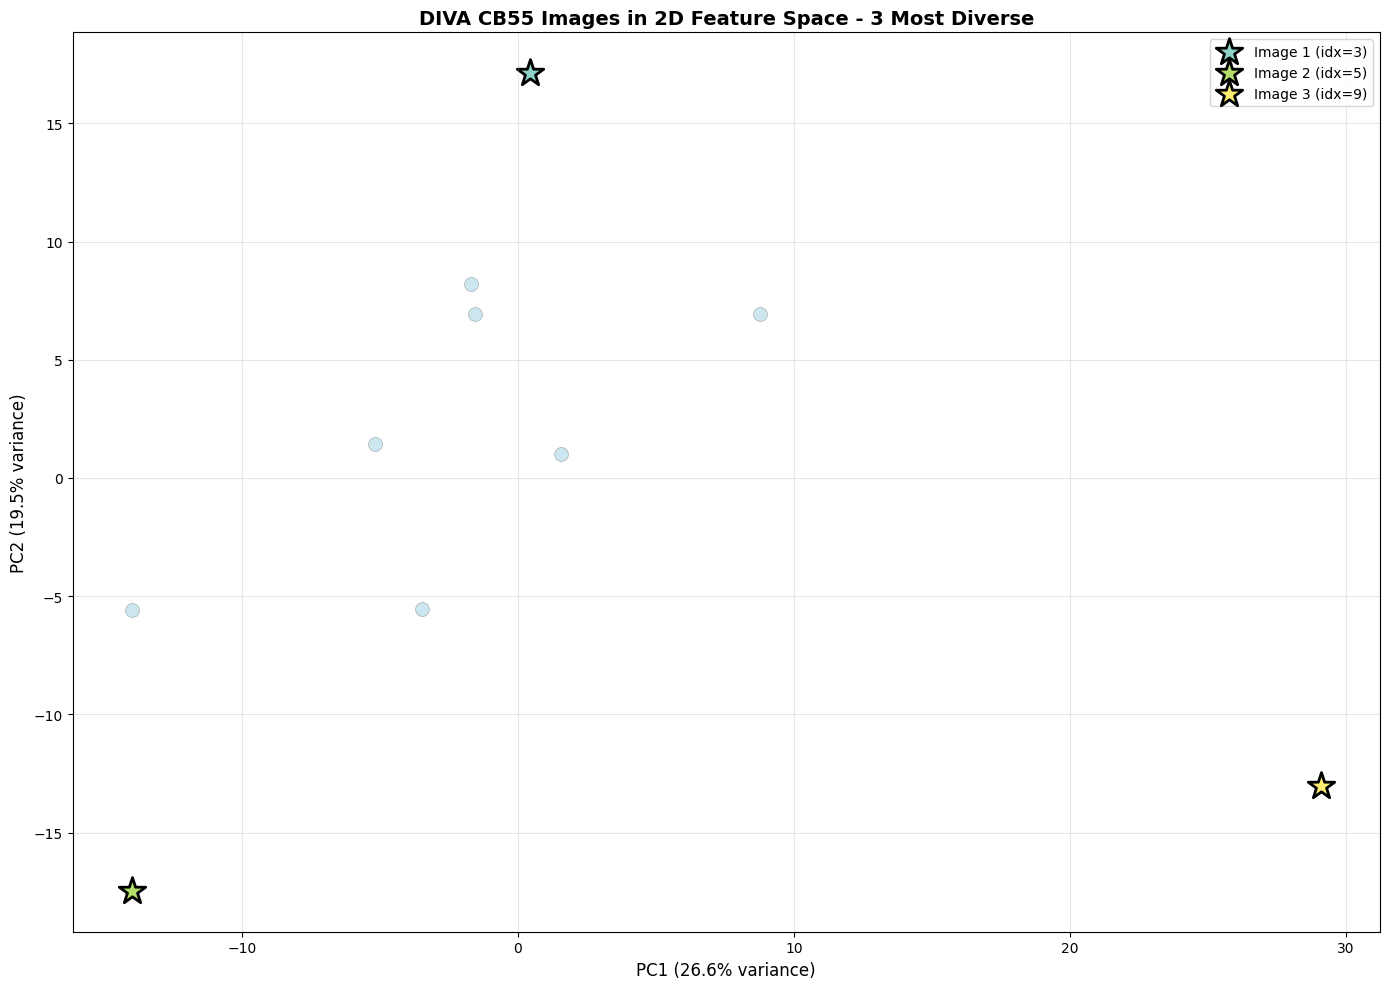

2D scatter plot saved as 'diva_cb55_2d_scatter.png'


In [14]:
# Create scatter plot with all images
fig, ax = plt.subplots(figsize=(14, 10))

# Plot all images
scatter = ax.scatter(features_2d[:, 0], features_2d[:, 1], 
                     c='lightblue', s=100, alpha=0.6, edgecolors='gray', linewidth=0.5)

# Generate colors for selected images
colors = plt.cm.Set3(np.linspace(0, 1, NUM_DIVERSE_IMAGES))

# Highlight the selected images
for idx, (color, img_idx) in enumerate(zip(colors, selected_indices)):
    ax.scatter(features_2d[img_idx, 0], features_2d[img_idx, 1], 
              s=400, color=color, marker='*', edgecolors='black', linewidth=2,
              label=f"Image {idx+1} (idx={img_idx})")

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)", fontsize=12)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)", fontsize=12)
ax.set_title(f"DIVA {DIVA_SUBSET} Images in 2D Feature Space - {NUM_DIVERSE_IMAGES} Most Diverse", 
            fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"diva_{DIVA_SUBSET.lower()}_2d_scatter.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"2D scatter plot saved as 'diva_{DIVA_SUBSET.lower()}_2d_scatter.png'")

## Display Selected Images

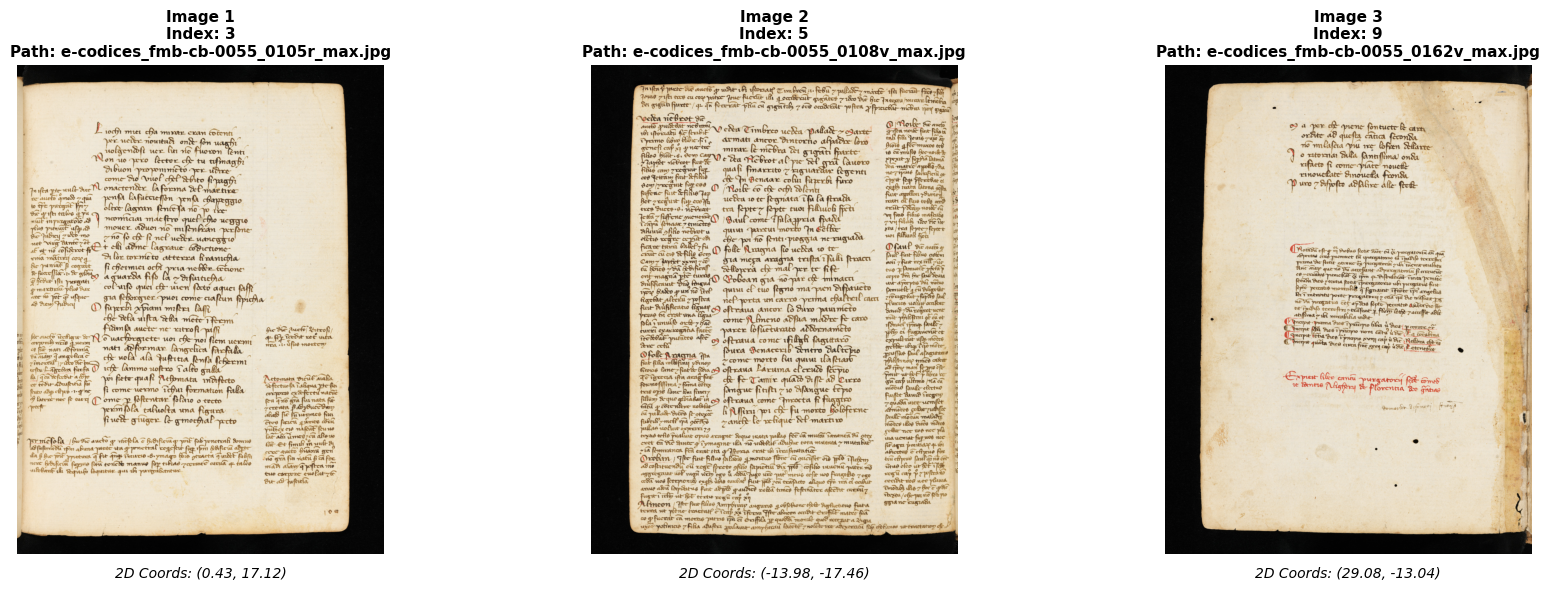

Selected images saved as 'diva_cb55_selected_images.png'

Selected image paths:
  Image 1: ../00_data/DIVA-HisDB/CB55/img-CB55/img/public-test/e-codices_fmb-cb-0055_0105r_max.jpg
  Image 2: ../00_data/DIVA-HisDB/CB55/img-CB55/img/public-test/e-codices_fmb-cb-0055_0108v_max.jpg
  Image 3: ../00_data/DIVA-HisDB/CB55/img-CB55/img/public-test/e-codices_fmb-cb-0055_0162v_max.jpg


In [15]:
# Display the selected images
fig, axes = plt.subplots(1, NUM_DIVERSE_IMAGES, figsize=(6*NUM_DIVERSE_IMAGES, 6))

# Handle case when NUM_DIVERSE_IMAGES == 1
if NUM_DIVERSE_IMAGES == 1:
    axes = [axes]

for idx, img_idx in enumerate(selected_indices):
    img_path = valid_images[img_idx]
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    axes[idx].imshow(img_rgb)
    axes[idx].set_title(f"Image {idx+1}\nIndex: {img_idx}\nPath: {img_path.name}", fontsize=11, fontweight='bold')
    axes[idx].axis('off')
    
    # Add 2D coordinates as text
    coords_text = f"2D Coords: ({features_2d[img_idx, 0]:.2f}, {features_2d[img_idx, 1]:.2f})"
    axes[idx].text(0.5, -0.05, coords_text, transform=axes[idx].transAxes, 
                  ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.savefig(f"diva_{DIVA_SUBSET.lower()}_selected_images.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Selected images saved as 'diva_{DIVA_SUBSET.lower()}_selected_images.png'")
print(f"\nSelected image paths:")
for idx, img_idx in enumerate(selected_indices, 1):
    print(f"  Image {idx}: {valid_images[img_idx]}")